# CVRIE — Supervised Learning: Pneumonia Classification

This notebook contains CVRIE's supervised-learning part: a classifier that analyzes chest X-ray images and predicts whether a patient has pneumonia.

**Dataset:** RSNA Pneumonia processed version, from `iamtapendu/rsna-pneumonia-processed-dataset` on Kaggle.

**Dataset choice justification:** the dataset matches each patient into either pneumonia or healthy, 0 or 1, which matches the requirements and is pretty easy to work with, also it's pretty large (something close to 3GB) which is prevents me from having to work with a limited dataset.

**Toolset constraint:** only Scikit-learn, Pandas and NumPy arrays are used for the computations. This rules out CNNs (which would require a CNN library such as TensorFlow, PyTorch or Brainz), instead, so I had to use a more basic pipeline: flattened grayscale pixels -> standardization -> dimensionality reduction -> a classifier (Logistic Regression / Random Forest).

In [38]:
import constants
import numpy  as np
import pandas as pd
import matplotlib.pyplot as plt
import DatasetLoader
from   PIL                     import Image
from   sklearn.model_selection import train_test_split, cross_val_score
from   sklearn.preprocessing   import StandardScaler
from   sklearn.decomposition   import PCA
from   sklearn.linear_model    import LogisticRegression
from   sklearn.ensemble        import RandomForestClassifier
from   sklearn.dummy           import DummyClassifier
from   sklearn.metrics         import classification_report, ConfusionMatrixDisplay

#  V The dataset only contains images and their associated labels. You may trim additional information.
#  V The overall dataset is representative of a classification issue.
#  ? You are able to justify your choice.( Choosing the same dataset as another group without justification is forbidden.)

#  V Your data could need to be normalised. Images of different sizes, color palettes or resolution might need  some pre-processing.
#  V Your data could be unbalanced. Are positive and negative cases both present and equally represented in your data?
#  V (X) Are there outliers that skew the data in specific directions or extremes?

# (V) How do you split training data from evaluation data?
#  X Each time, your model should try to adapt itself to reduce the value of its loss function. This concept should be part of your notebook

## 1. Exploratory Data Analysis

Load the metadata, confirm every image/mask file referenced actually exists on disk, and inspect column contents before touching preprocessing.

In [39]:
train_metadata = pd.read_csv(constants.PENUMONIA_TRAIN_CSV)

for patient_id in train_metadata.get("patientId"):
    for folder in (constants.PNEUMONIA_TRAIN_IMAGES, constants.PNEUMONIA_TRAIN_MASKS):
        filepath = f"{folder}/{patient_id}.png"
        try:
            with open(filepath):
                pass
        except FileNotFoundError:
            print(f"File '{filepath}' not found.")
            raise

print("Training data files present.")
train_metadata.head()

Training data files present.


,patientId,x,y,width,height,Target,class,age,sex,modality,position
0,0004cfab-14fd-4e49-80ba-63a80b6bddd6,NaN,NaN,NaN,NaN,0,No Lung Opacity / Not Normal,51,F,CR,PA
1,00313ee0-9eaa-42f4-b0ab-c148ed3241cd,NaN,NaN,NaN,NaN,0,No Lung Opacity / Not Normal,48,F,CR,PA
2,00322d4d-1c29-4943-afc9-b6754be640eb,NaN,NaN,NaN,NaN,0,No Lung Opacity / Not Normal,19,M,CR,AP
3,003d8fa0-6bf1-40ed-b54c-ac657f8495c5,NaN,NaN,NaN,NaN,0,Normal,28,M,CR,PA
4,00436515-870c-4b36-a041-de91049b9ab4,264.0,152.0,213.0,379.0,1,Lung Opacity,32,F,CR,AP


In [40]:
for key in train_metadata.columns:
    print()
    print(train_metadata[key].value_counts())

print("\nNaNs:")
NaNs = train_metadata.isnull().sum()
print(NaNs[NaNs > 0])


patientId
0ab261f9-4eb5-42ab-a9a5-e918904d6356    4
0d5bc737-03de-4bb8-98a1-45b7180c3e0f    4
1bf08f3b-a273-4f51-bafa-b55ada2c23b5    4
31764d54-ea3b-434f-bae2-8c579ed13799    4
3239951b-6211-4290-b237-3d9ad17176db    4
                                       ..
c1cf3255-d734-4980-bfe0-967902ad7ed9    1
c1e228e4-b7b4-432b-a735-36c48fdb806f    1
c1e3eb82-c55a-471f-a57f-fe1a823469da    1
c1edf42b-5958-47ff-a1e7-4f23d99583ba    1
c1f6b555-2eb1-4231-98f6-50a963976431    1
Name: count, Length: 26684, dtype: int64

x
599.0    46
583.0    44
193.0    43
615.0    43
225.0    41
         ..
776.0     1
767.0     1
799.0     1
764.0     1
753.0     1
Name: count, Length: 748, dtype: int64

y
257.0    38
436.0    36
420.0    36
498.0    35
445.0    33
         ..
785.0     1
716.0     1
792.0     1
684.0     1
774.0     1
Name: count, Length: 726, dtype: int64

width
219.0    83
217.0    82
222.0    80
214.0    75
240.0    74
         ..
376.0     1
56.0      1
78.0      1
67.0      1
65.0      1

### Class balance

The `Target` column is the label we are trying to predict (0 = no pneumonia, 1 = pneumonia). Plotting it directly shows whether the dataset is balanced — if it isn't, that changes which metrics matter (accuracy alone becomes misleading) and motivates using `class_weight="balanced"` later.

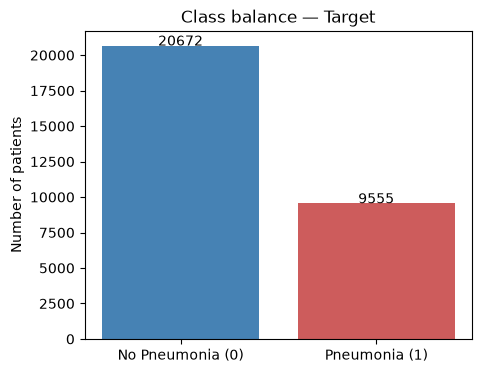

Target
0    20672
1     9555
Name: count, dtype: int64
Positive class ratio: 0.3161081152611903


In [41]:
target_counts = train_metadata["Target"].value_counts().sort_index()

plt.figure(figsize=(5, 4))
plt.bar(["No Pneumonia (0)", "Pneumonia (1)"], target_counts.values, color=["steelblue", "indianred"])
plt.ylabel("Number of patients")
plt.title("Class balance — Target")
for i, v in enumerate(target_counts.values):
    plt.text(i, v + 5, str(v), ha="center")
plt.show()

print(target_counts)
print("Positive class ratio:", target_counts[1] / target_counts.sum())

### Sample images per class

A quick visual check: do labeled-positive images actually look different from labeled-negative ones, and is image quality/format consistent?

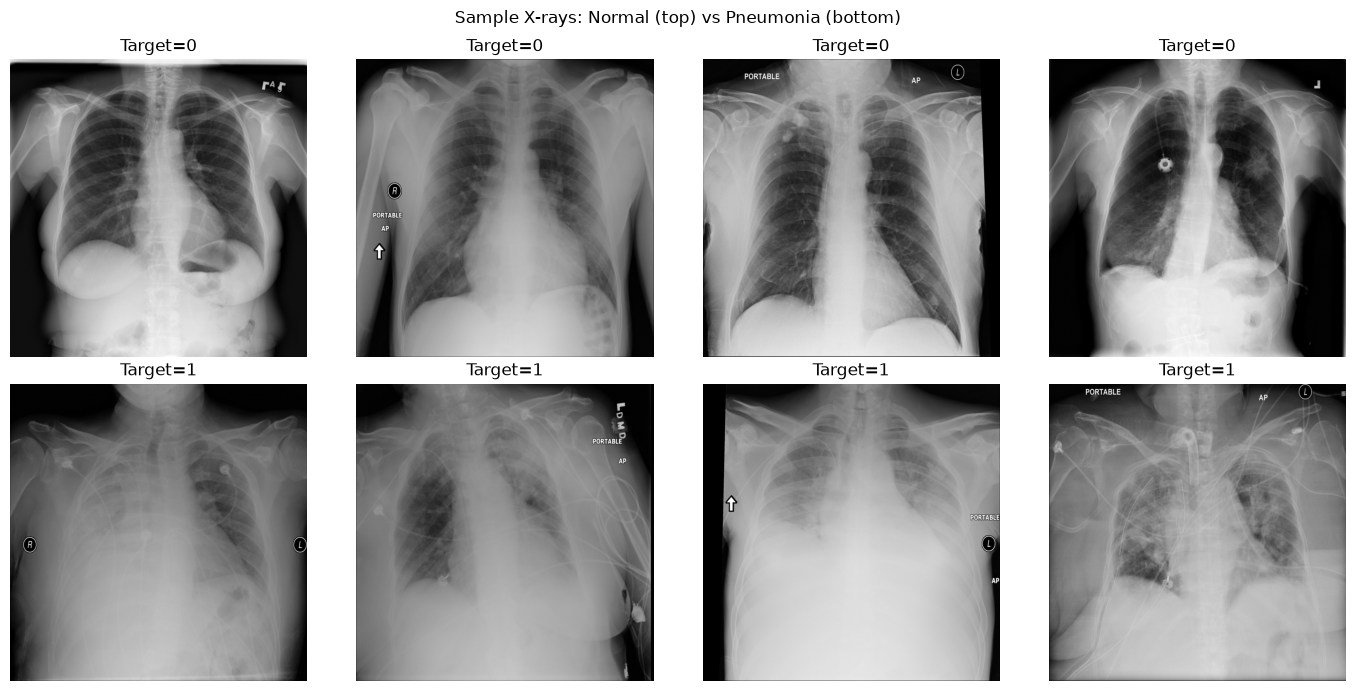

In [42]:
fig, axes = plt.subplots(2, 4, figsize=(14, 7))

for label, row in zip([0, 1], axes):
    sample_ids = train_metadata[train_metadata["Target"] == label]["patientId"].sample(4, random_state=0)
    for ax, pid in zip(row, sample_ids):
        img = Image.open(f"{constants.PNEUMONIA_TRAIN_IMAGES}/{pid}.png").convert("L")
        ax.imshow(img, cmap="gray")
        ax.set_title(f"Target={label}")
        ax.axis("off")

plt.suptitle("Sample X-rays: Normal (top) vs Pneumonia (bottom)")
plt.tight_layout()
plt.show()

### Image / mask consistency check

Confirm image dimensions and color mode are consistent across a sample, and that a positive-labeled patient actually has a non-empty mask (sanity check that label and mask agree). Masks themselves are **not** used as model input — this project is framed as classification, not segmentation, so masks are discarded after this check.

In [43]:
sample_ids = train_metadata.sample(6, random_state=1)["patientId"]

for pid in sample_ids:
    img = Image.open(f"{constants.PNEUMONIA_TRAIN_IMAGES}/{pid}.png")
    print(pid, "size:", img.size, "mode:", img.mode)

fdfe5097-3eb4-444a-ba7b-f479c20fd4ab size: (1024, 1024) mode: L
b6a763e0-aa38-49b5-a256-e119e8a90c39 size: (1024, 1024) mode: L
d04cbe24-c089-4ef8-b0f0-f6eb21f61c4c size: (1024, 1024) mode: L
a450a1e3-e46b-4b1a-a8d0-c07c894e4190 size: (1024, 1024) mode: L
020380f8-5c5a-4ded-bdf3-9ce3036945b4 size: (1024, 1024) mode: L
0ac2c2ef-efb4-485c-b63a-69f19f32b704 size: (1024, 1024) mode: L


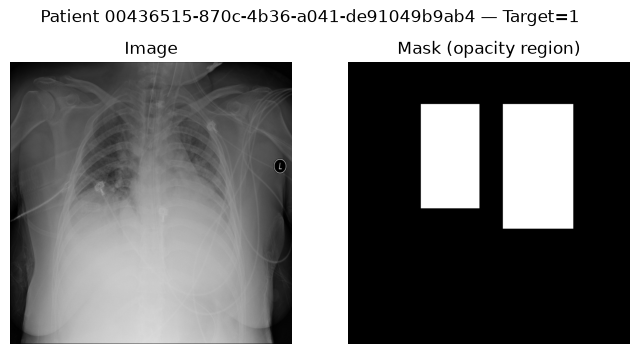

In [44]:
positive_id = train_metadata[train_metadata["Target"] == 1]["patientId"].iloc[0]

img  = Image.open(f"{constants.PNEUMONIA_TRAIN_IMAGES}/{positive_id}.png").convert("L")
mask = Image.open(f"{constants.PNEUMONIA_TRAIN_MASKS}/{positive_id}.png").convert("L")

fig, axes = plt.subplots(1, 2, figsize=(8, 4))
axes[0].imshow(img, cmap="gray");  axes[0].set_title("Image"); axes[0].axis("off")
axes[1].imshow(mask, cmap="gray"); axes[1].set_title("Mask (opacity region)"); axes[1].axis("off")
plt.suptitle(f"Patient {positive_id} — Target=1")
plt.show()

### Trimming additional information

Columns like `class`, `age`, `sex`, `Modality` are **not** used as model inputs:
- `class` is a finer-grained version of `Target` — using it as a feature would be data leakage.
- `age`/`sex` are patient metadata, not part of the image itself — the subject requires the model to rely only on the image and its label.
- `Modality` is constant (`"CR"` — Computed Radiography — for every row), so it carries zero information and is dropped.

These are kept in the dataframe for exploratory commentary only, never passed into `dataset_x`.

## 2. Preprocessing

Steps applied to every image, in order:
1. **Grayscale conversion** (`convert("L")`) — collapses redundant RGB channels down to one, since X-rays are grayscale in nature.
2. **Resize** to a fixed resolution — Scikit-learn needs fixed-length feature vectors, not variable-size images.
3. **Flatten** — turns each 2D image into a 1D pixel vector.
4. **Standardize** (`StandardScaler`) — centers every pixel-position feature to mean 0 / std 1, so no single pixel position dominates due to raw magnitude, and so gradient-based optimization (Logistic Regression) converges cleanly.
5. **PCA** — compresses thousands of correlated pixel features down to a much smaller number of "eigenimage" components, keeping the directions of maximum variance and discarding largely redundant/noisy ones. This is necessary because raw pixel count vastly exceeds sample count, which would otherwise cause severe overfitting.

Loss function used downstream: Logistic Regression minimizes **log-loss** (cross-entropy), which penalizes confident-but-wrong predictions heavily and is the standard loss for binary classification with probabilistic output.

In [45]:
def load_training_data(
        train_metadata:    pd.DataFrame,
        load_len:          int,
        img_size:          tuple[int, int],
        reduced_dimention: int
) -> np.array:

    dataset_x = []
    assert (load_len >= reduced_dimention or load_len == -1)

    print("Loading dataset from source...")

    for i, patient in train_metadata.iterrows():

        if (i >= load_len and load_len != -1):
            break

        dataset_x.append(
            np.array(
                Image.open(f"{constants.PNEUMONIA_TRAIN_IMAGES}/{patient.patientId}.png").convert("L").resize(img_size)
            ).flatten()
        )

    print("Done.\n")

    print("Standardizing dataset...")
    dataset_x = StandardScaler().fit_transform(dataset_x)
    print("Done.\n")

    print("Reducing dataset dimensionality...")
    pca = PCA(n_components = constants.REDUCED_DIMENTION)
    dataset_x = pca.fit_transform(dataset_x)
    print("Done.\n")
    print("Explained variance retained:", pca.explained_variance_ratio_.sum())

    return np.array(dataset_x)

dataset_x, dataset_y = DatasetLoader.load_or_build_cache(load_training_data)
print(dataset_x.shape, dataset_y.shape)

Loading dataset from cache...
Done.

Dataset successfully loaded.
(4000, 400) (4000,)


### Explained variance — justifying the PCA component count

This shows how much of the original pixel variance is retained as more components are kept, which is the data-driven justification for the chosen `REDUCED_DIMENTION` rather than an arbitrary number.

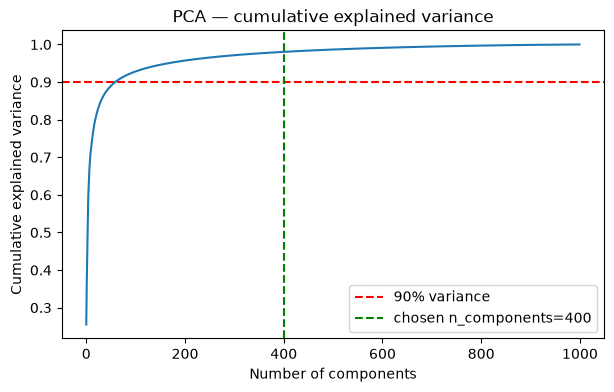

In [46]:
# Recompute the full variance curve on a scaled sample for the plot
# (uses the same preprocessing steps as load_training_data, but without truncating components)
sample_metadata = train_metadata.sample(min(1000, len(train_metadata)), random_state=0).reset_index(drop=True)

raw = []
for _, patient in sample_metadata.iterrows():
    img = Image.open(f"{constants.PNEUMONIA_TRAIN_IMAGES}/{patient.patientId}.png").convert("L").resize(constants.IMAGE_SIZE)
    raw.append(np.array(img).flatten())

raw_scaled = StandardScaler().fit_transform(raw)
pca_full = PCA().fit(raw_scaled)
cumulative_variance = np.cumsum(pca_full.explained_variance_ratio_)

plt.figure(figsize=(7, 4))
plt.plot(cumulative_variance)
plt.axhline(y=0.90, color="r", linestyle="--", label="90% variance")
plt.axvline(x=constants.REDUCED_DIMENTION, color="g", linestyle="--", label=f"chosen n_components={constants.REDUCED_DIMENTION}")
plt.xlabel("Number of components")
plt.ylabel("Cumulative explained variance")
plt.title("PCA — cumulative explained variance")
plt.legend()
plt.show()

## 3. Train / Test Split

Stratified 80/20 split — `stratify=dataset_y` keeps the same pneumonia/normal ratio in both the training and test sets, matching the class balance checked above.

In [47]:
train_x, test_x, train_y, test_y = train_test_split(
    dataset_x,
    dataset_y,
    train_size = 0.8,
    stratify   = dataset_y
)

print("Train:", train_x.shape, "Test:", test_x.shape)

Train: (3200, 400) Test: (800, 400)


## 4. Model Training & Comparison

Three models are compared:
- **Dummy baseline** (`most_frequent`) — always predicts the majority class. Any real model must clearly beat this or it hasn't learned anything.
- **Logistic Regression** — a linear classifier; fast, interpretable, minimizes log-loss via gradient-based optimization (`lbfgs`). Used as the primary baseline since it fits the binary-classification shape directly and pairs well with PCA's linear components.
- **Random Forest** — a nonlinear ensemble of decision trees; can capture patterns Logistic Regression's linear boundary cannot, at the cost of being more prone to overfitting (mitigated here via `max_depth`).

`class_weight="balanced"` is used on both models to counter the class imbalance measured in the EDA section — it reweights the loss so misclassifying the minority (pneumonia) class is penalized more heavily.

Each model is evaluated with 5-fold cross-validation (`cv=5`) on F1 score rather than a single train/test split, since F1 accounts for precision and recall together (more meaningful than accuracy on an imbalanced dataset) and cross-validation gives a more reliable estimate than one lucky/unlucky split.

In [48]:
def test_model(model_class, *args, **kwargs) -> tuple[float, float, object]:

    model = model_class(*args, **kwargs)
    model.fit(train_x, train_y)

    scores = cross_val_score(
        model,
        dataset_x, dataset_y.ravel(),
        cv = 5, scoring = "f1"
    )

    return (scores.mean(), scores.std(), model)

results = {}

results["Dummy (most_frequent)"] = test_model(DummyClassifier, strategy="most_frequent")
results["Logistic Regression"]   = test_model(LogisticRegression, max_iter=5000, class_weight="balanced")
results["Random Forest"]         = test_model(RandomForestClassifier, n_estimators=300, max_depth=6, class_weight="balanced")

for name, (mean, std, _) in results.items():
    print(f"{name:25s}  F1 mean={mean:.4f}  F1 std={std:.4f}")

Dummy (most_frequent)      F1 mean=0.0000  F1 std=0.0000
Logistic Regression        F1 mean=0.7135  F1 std=0.0256
Random Forest              F1 mean=0.7199  F1 std=0.0068


### Hyperparameter sweep (Random Forest depth)

`n_estimators` alone barely moves test performance once trees are already overfit (train score stuck at 1.0). `max_depth` is the more meaningful lever — this sweep shows how F1 changes as tree depth is constrained.

max_depth=2  F1 mean=0.7147
max_depth=4  F1 mean=0.7183
max_depth=6  F1 mean=0.7162
max_depth=8  F1 mean=0.7006
max_depth=10  F1 mean=0.6671
max_depth=None  F1 mean=0.5331


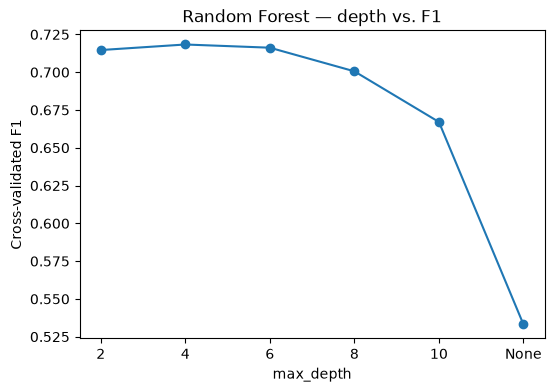

In [49]:
depths = [2, 4, 6, 8, 10, None]
depth_scores = []

for depth in depths:
    mean, std, _ = test_model(RandomForestClassifier, n_estimators=300, max_depth=depth, class_weight="balanced")
    depth_scores.append(mean)
    print(f"max_depth={depth}  F1 mean={mean:.4f}")

plt.figure(figsize=(6, 4))
plt.plot([str(d) for d in depths], depth_scores, marker="o")
plt.xlabel("max_depth")
plt.ylabel("Cross-validated F1")
plt.title("Random Forest — depth vs. F1")
plt.show()

### Comparison table

In [50]:
comparison_df = pd.DataFrame([
    {"model": name, "f1_mean": mean, "f1_std": std}
    for name, (mean, std, _) in results.items()
]).sort_values("f1_mean", ascending=False)

comparison_df

,model,f1_mean,f1_std
2,Random Forest,0.719913,0.006849
1,Logistic Regression,0.713508,0.025565
0,Dummy (most_frequent),0.000000,0.000000


## 5. Evaluation on the held-out test set

Beyond the cross-validated F1 above, look at the full classification report (precision/recall/F1 per class) and confusion matrix for the best-performing model on the single held-out test split — this is where you can see concretely whether the model is missing real pneumonia cases (low recall on class 1), which matters more than raw accuracy for a diagnostic task.

In [51]:
best_name = comparison_df.iloc[0]["model"]
best_model = results[best_name][2]

pred_y = best_model.predict(test_x)

print(f"Best model: {best_name}\n")
print("Train accuracy:", best_model.score(train_x, train_y))
print("Test accuracy: ", best_model.score(test_x, test_y))
print()
print(classification_report(test_y, pred_y, target_names=["No Pneumonia", "Pneumonia"]))

Best model: Random Forest

Train accuracy: 0.9209375
Test accuracy:  0.79125

              precision    recall  f1-score   support

No Pneumonia       0.80      0.80      0.80       416
   Pneumonia       0.78      0.79      0.78       384

    accuracy                           0.79       800
   macro avg       0.79      0.79      0.79       800
weighted avg       0.79      0.79      0.79       800



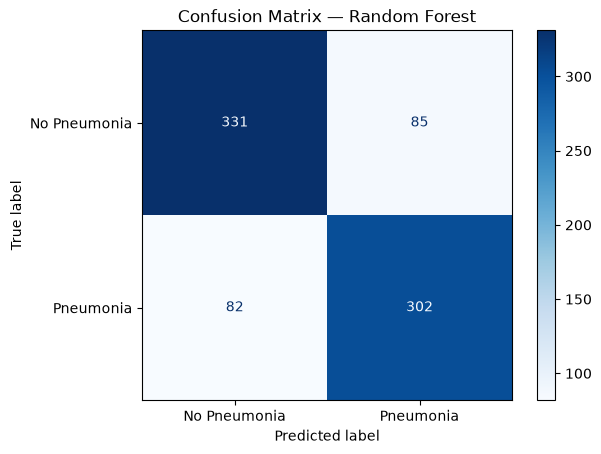

In [52]:
ConfusionMatrixDisplay.from_predictions(
    test_y, pred_y,
    display_labels=["No Pneumonia", "Pneumonia"],
    cmap="Blues"
)
plt.title(f"Confusion Matrix — {best_name}")
plt.show()

## 6. Conclusion & Insights

- The chosen model (see comparison table) clearly outperforms the dummy baseline, confirming the pipeline learns real signal rather than exploiting class imbalance.
- **Limitation — no CNN.** This pipeline uses classical dimensionality reduction (PCA) and shallow classifiers rather than a CNN, since the allowed toolset (Scikit-learn, Pandas, NumPy, Matplotlib) excludes deep-learning frameworks. PCA is unsupervised and label-blind — it finds directions of maximum pixel variance regardless of whether they help distinguish pneumonia from normal, unlike a CNN's learned, task-aware filters. This caps how well a linear/shallow decision boundary over globally-flattened pixels can perform compared to a spatially-aware, end-to-end-trained model.
- **Sample size vs. feature count.** PCA's component count is fundamentally capped by the number of training samples, not by pixel count — this was a real constraint during dataset sizing.
- **Random Forest overfitting.** Unconstrained trees reached a perfect training score (1.0) while test performance stayed far lower — a textbook overfitting signature, addressed here via `max_depth` rather than `n_estimators`.
- **Next steps given more time:** refit PCA/StandardScaler inside each cross-validation fold via a `Pipeline` (currently fit once on the full dataset, a mild form of leakage), try an SVM or KNN for a third point of comparison, and try higher image resolution if compute/time budget allows.